# MISION: Reconocimiento del Paciente

**Objetivo:** 5,110 historiales clinicos. Solo 249 tuvieron ictus (stroke). Tu mision: entender que distingue a esos 249 del resto.

---

### Contexto

El ictus (stroke) es la **segunda causa de muerte a nivel mundial** segun la OMS, responsable de ~11% de las muertes totales. La deteccion temprana de factores de riesgo puede marcar la diferencia entre vida y muerte.

Tenemos un dataset con datos clinicos y demograficos de 5,110 pacientes. El reto: con solo un **4.9% de casos positivos**, encontrar las senales que predicen un ictus es como buscar agujas en un pajar.

**Regla de oro:** Entender los datos ANTES de modelar. Un modelo sin EDA es una pistola sin mira.

## 1. Imports y Configuracion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')

# Estilo y colores
plt.style.use('seaborn-v0_8-whitegrid')
NO_STROKE = '#2ecc71'
STROKE = '#e74c3c'
COLORS = [NO_STROKE, STROKE]

# Rutas
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data", "heart_attack")

print(f"Proyecto: {project_root}")
print(f"Datos: {data_dir}")

Proyecto: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos
Datos: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/heart_attack


## 2. Carga de Datos

In [2]:
df = pd.read_csv(os.path.join(data_dir, "healthcare-dataset-stroke-data.csv"))
df.drop(columns=['id'], inplace=True)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")

Dimensiones: 5110 filas x 11 columnas
Columnas: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [4]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


## 3. Balance de Clases — LA PIEZA CRITICA

Antes de cualquier otra cosa: cuantos pacientes tuvieron ictus?

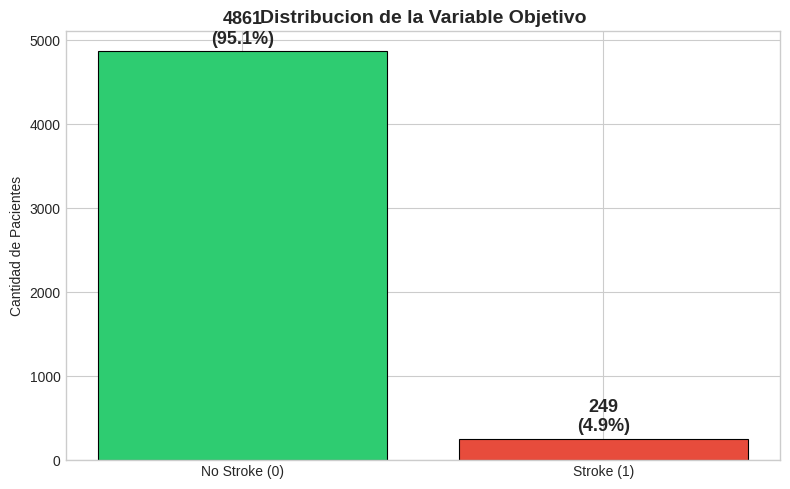

No stroke: 4861 (95.1%)
Stroke:    249 (4.9%)
Ratio:     20:1


In [6]:
counts = df['stroke'].value_counts().sort_index()
pcts = df['stroke'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['No Stroke (0)', 'Stroke (1)'], counts.values, color=COLORS, edgecolor='black', linewidth=0.8)

for bar, count, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_title('Distribucion de la Variable Objetivo', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad de Pacientes')
plt.tight_layout()
plt.show()

print(f"No stroke: {counts[0]} ({pcts[0]:.1f}%)")
print(f"Stroke:    {counts[1]} ({pcts[1]:.1f}%)")
print(f"Ratio:     {counts[0]/counts[1]:.0f}:1")

### Leccion critica

Si tu modelo dice **"no stroke" SIEMPRE**, acierta el **95.1%**. Accuracy es **INUTIL** aqui.

Metricas que importan: **Recall**, **F1-score**, **AUC-ROC**. Un modelo que no detecta ictus es peor que inutil — es peligroso.

## 4. Analisis de Nulos

In [7]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': null_pct})
null_df = null_df[null_df['Nulos'] > 0]
print("Columnas con valores nulos:")
print(null_df)
print(f"\nBMI tiene {nulls['bmi']} nulos ({null_pct['bmi']}%)")

Columnas con valores nulos:
     Nulos  Porcentaje (%)
bmi    201            3.93

BMI tiene 201 nulos (3.93%)


In [8]:
# smoking_status tiene "Unknown" — no es nulo tecnico, pero es dato faltante
smoking_counts = df['smoking_status'].value_counts()
print("Distribucion de smoking_status:")
print(smoking_counts)
print(f"\n'Unknown' representa {smoking_counts.get('Unknown', 0)} casos "
      f"({smoking_counts.get('Unknown', 0)/len(df)*100:.1f}%)")
print("\nNo es un nulo clasico. Puede ser informativo: 'no se pregunto' = perfil demografico distinto.")

Distribucion de smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

'Unknown' representa 1544 casos (30.2%)

No es un nulo clasico. Puede ser informativo: 'no se pregunto' = perfil demografico distinto.


## 5. Distribuciones Numericas por Stroke

Comparamos las distribuciones de las variables numericas entre pacientes con y sin ictus.

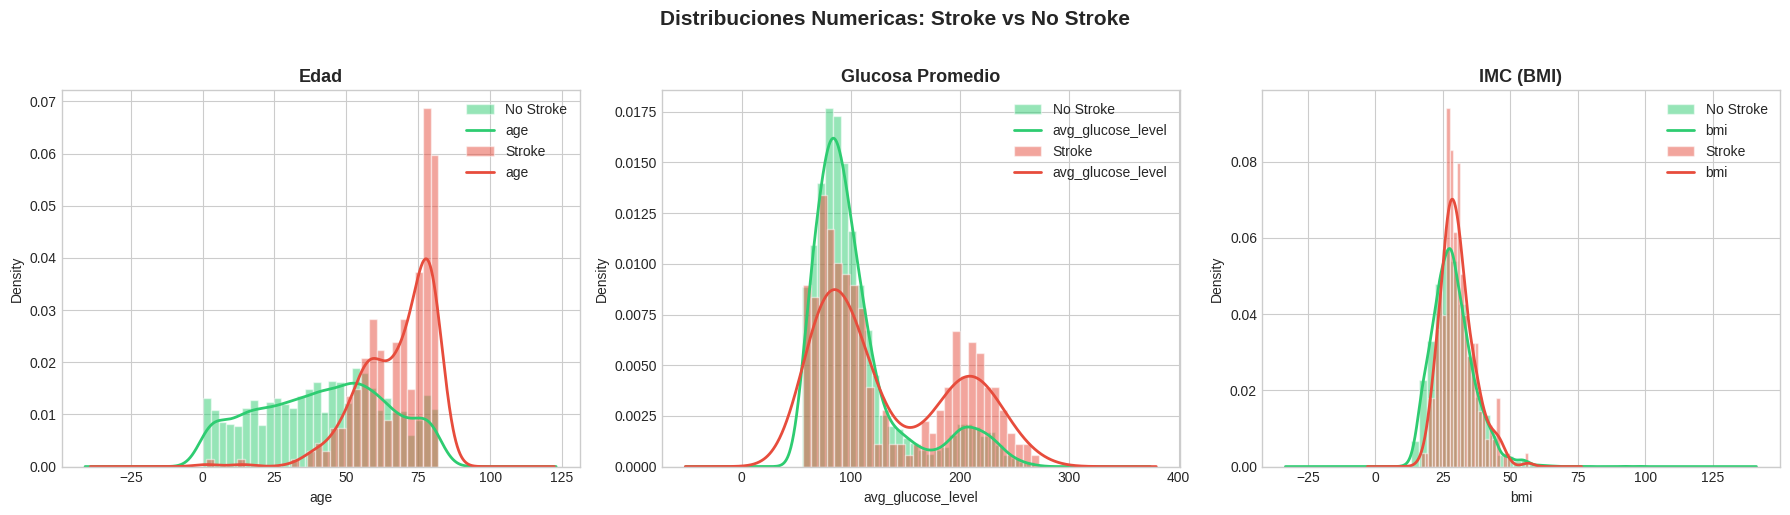

In [9]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
titles = ['Edad', 'Glucosa Promedio', 'IMC (BMI)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, numeric_cols, titles):
    for val, color, label in [(0, NO_STROKE, 'No Stroke'), (1, STROKE, 'Stroke')]:
        subset = df[df['stroke'] == val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True, edgecolor='white')
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Distribuciones Numericas: Stroke vs No Stroke', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Hallazgo clave:** El stroke es casi inexistente en menores de 40 anios. La edad es, por lejos, el factor mas discriminante a primera vista.

## 6. Edad — Inmersion Profunda

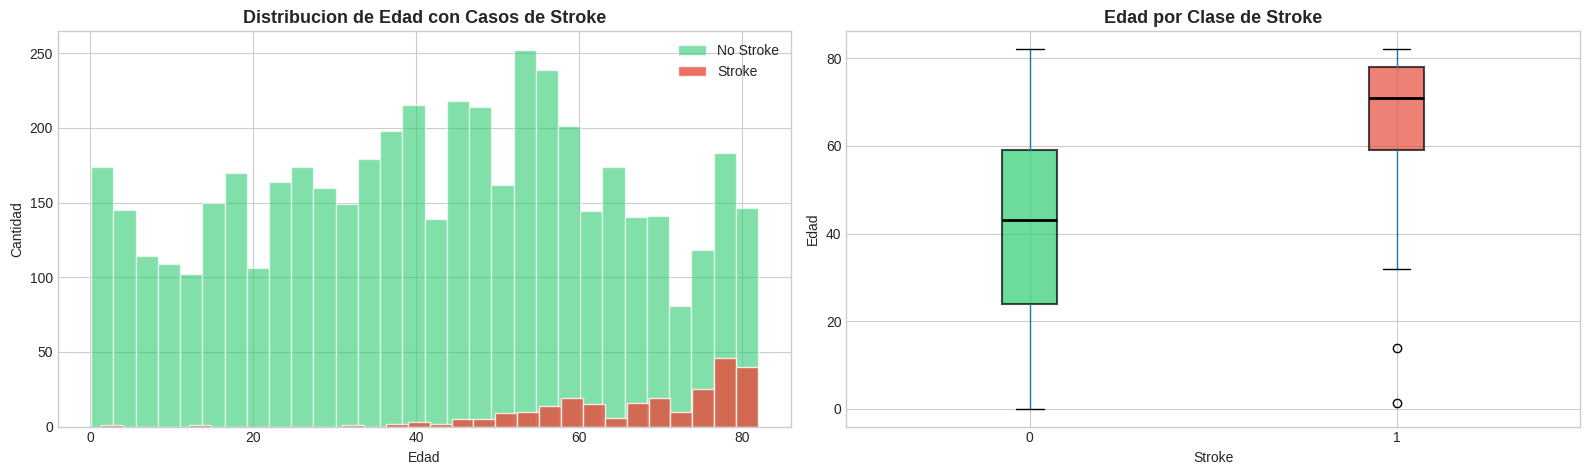

Edad media sin stroke: 42.0
Edad media con stroke: 67.7


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma con casos de stroke resaltados
ax = axes[0]
ax.hist(df[df['stroke'] == 0]['age'], bins=30, alpha=0.6, color=NO_STROKE, label='No Stroke', edgecolor='white')
ax.hist(df[df['stroke'] == 1]['age'], bins=30, alpha=0.8, color=STROKE, label='Stroke', edgecolor='white')
ax.set_title('Distribucion de Edad con Casos de Stroke', fontsize=13, fontweight='bold')
ax.set_xlabel('Edad')
ax.set_ylabel('Cantidad')
ax.legend()

# Box plot por stroke
ax = axes[1]
bp = df.boxplot(column='age', by='stroke', ax=ax, patch_artist=True,
                boxprops=dict(linewidth=1.5),
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(ax.patches if hasattr(ax, 'patches') else bp.patches if hasattr(bp, 'patches') else [], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Edad por Clase de Stroke', fontsize=13, fontweight='bold')
ax.set_xlabel('Stroke')
ax.set_ylabel('Edad')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Edad media sin stroke: {df[df['stroke']==0]['age'].mean():.1f}")
print(f"Edad media con stroke: {df[df['stroke']==1]['age'].mean():.1f}")

## 7. Distribuciones Categoricas con Proporcion de Stroke

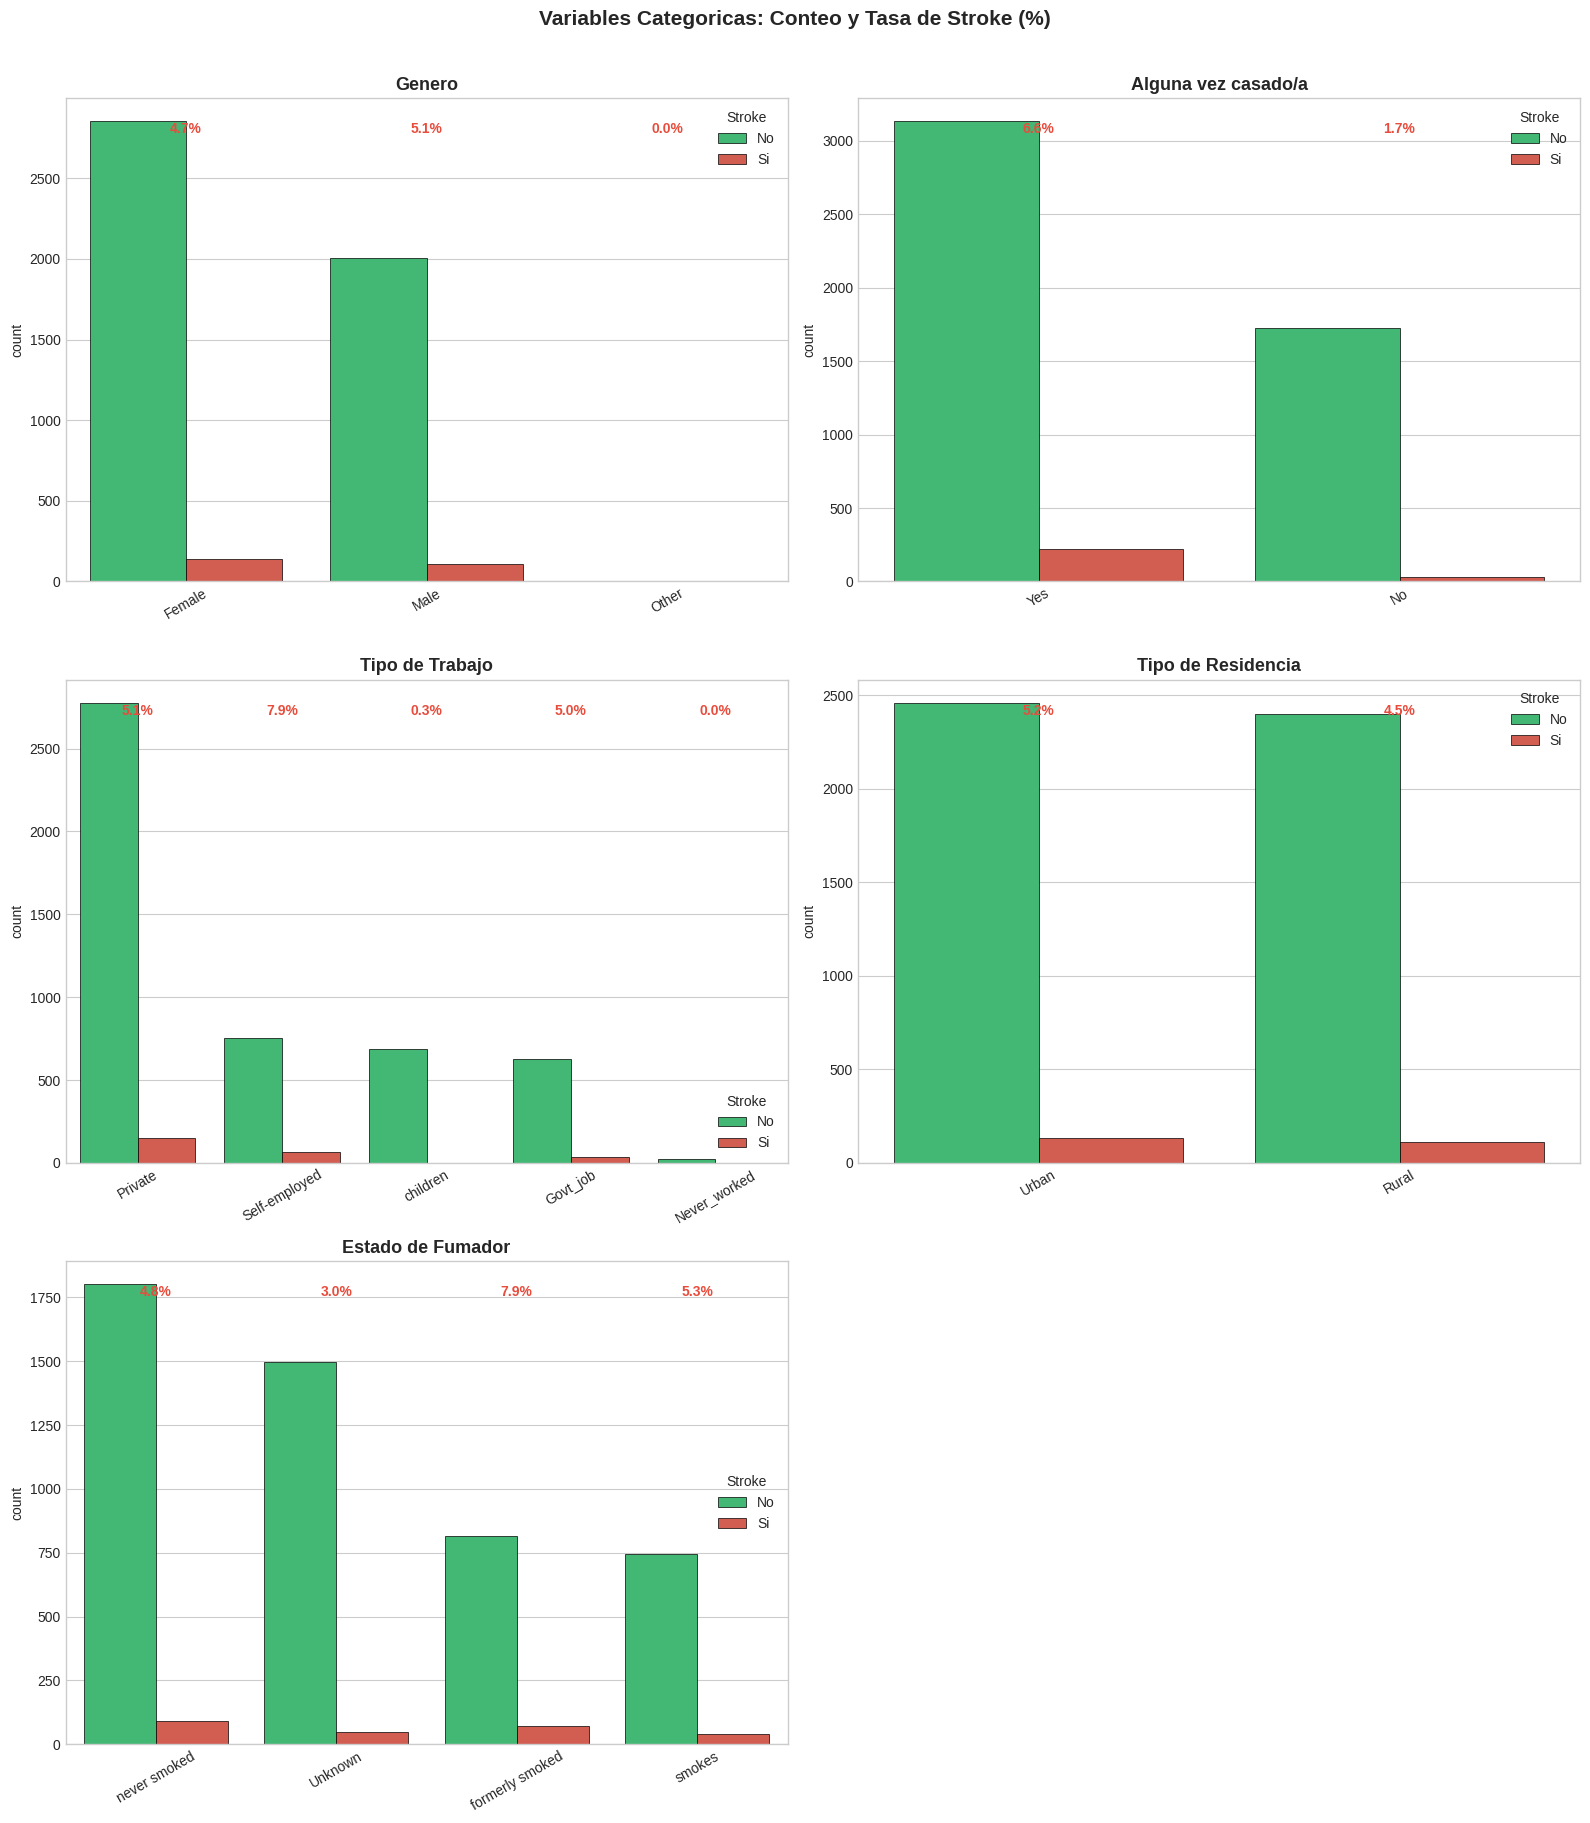

In [11]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
cat_titles = ['Genero', 'Alguna vez casado/a', 'Tipo de Trabajo', 'Tipo de Residencia', 'Estado de Fumador']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, (col, title) in enumerate(zip(cat_cols, cat_titles)):
    ax = axes[idx]
    
    # Conteo por categoria
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue='stroke', order=order, ax=ax,
                  palette={0: NO_STROKE, 1: STROKE}, edgecolor='black', linewidth=0.5)
    
    # Anotar proporcion de stroke en cada barra
    for cat in order:
        total = len(df[df[col] == cat])
        strokes = len(df[(df[col] == cat) & (df['stroke'] == 1)])
        rate = strokes / total * 100 if total > 0 else 0
        # Posicionar texto sobre la categoria
        cat_idx = list(order).index(cat)
        ax.text(cat_idx, ax.get_ylim()[1] * 0.95, f'{rate:.1f}%',
                ha='center', va='top', fontsize=10, fontweight='bold', color=STROKE)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Stroke', labels=['No', 'Si'])

# Ocultar el subplot sobrante
axes[-1].set_visible(False)

plt.suptitle('Variables Categoricas: Conteo y Tasa de Stroke (%)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Mapa de Correlacion (Variables Numericas)

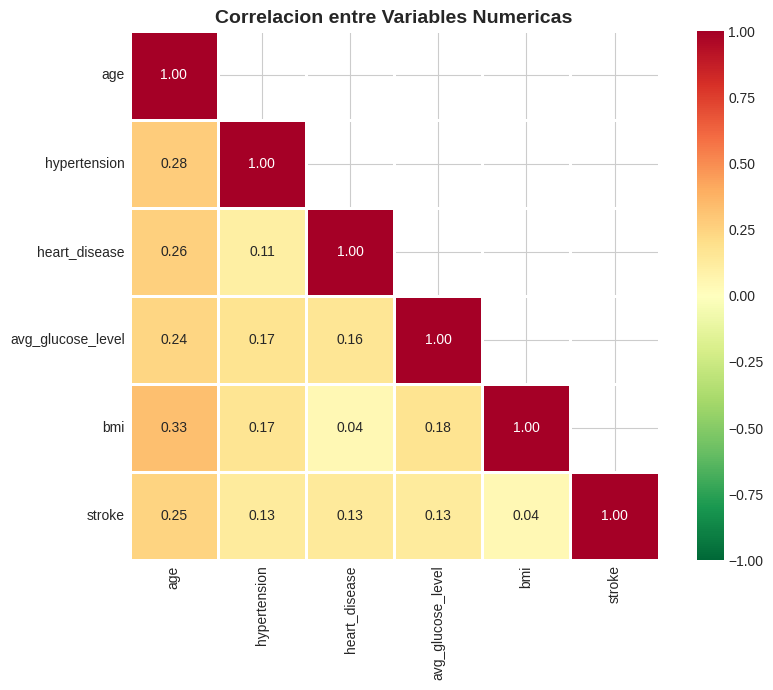

Correlaciones con 'stroke':
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374


In [12]:
numeric_for_corr = df[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']].copy()
corr_matrix = numeric_for_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            mask=mask, square=True, linewidths=1, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlacion entre Variables Numericas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlaciones con 'stroke':")
print(corr_matrix['stroke'].drop('stroke').sort_values(ascending=False).to_string())

## 9. Bivariado: Edad vs Glucosa (coloreado por Stroke)

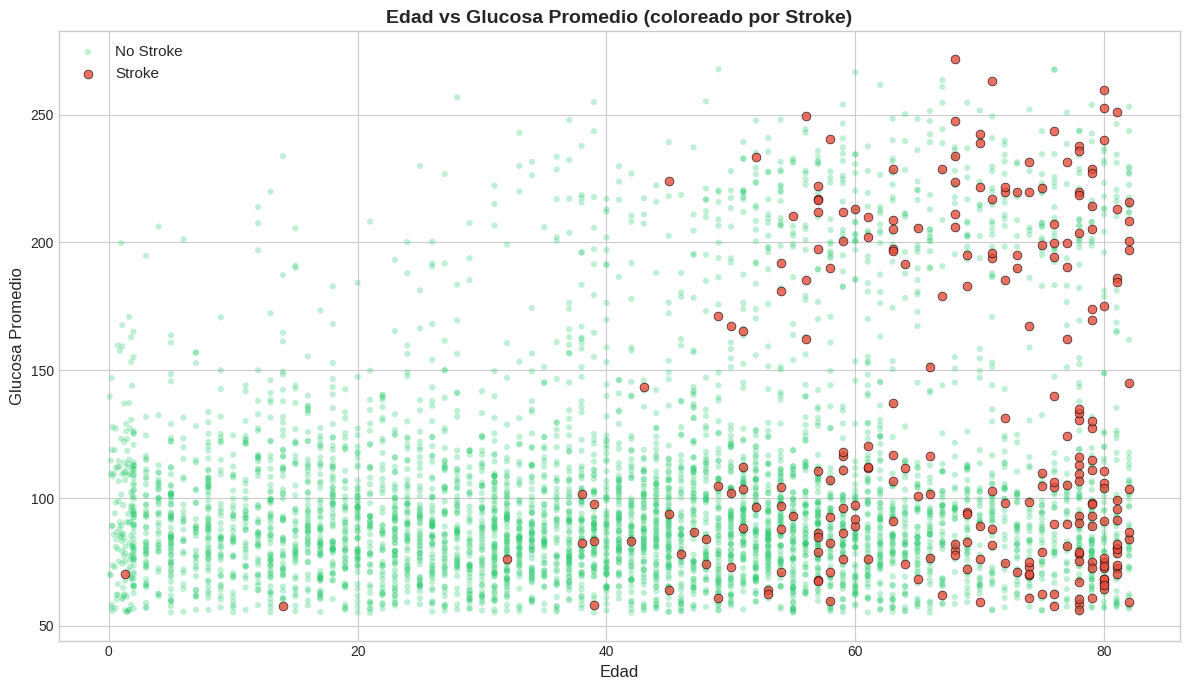

Observacion: Los casos de stroke se concentran en edad > 40 y se dispersan en glucosa.
No hay un umbral claro de glucosa, pero la combinacion edad alta + glucosa alta parece arriesgada.


In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

# Primero no-stroke (fondo), luego stroke (encima)
no_s = df[df['stroke'] == 0]
s = df[df['stroke'] == 1]

ax.scatter(no_s['age'], no_s['avg_glucose_level'], c=NO_STROKE, alpha=0.3, s=20, label='No Stroke', edgecolors='none')
ax.scatter(s['age'], s['avg_glucose_level'], c=STROKE, alpha=0.8, s=40, label='Stroke', edgecolors='black', linewidth=0.5)

ax.set_title('Edad vs Glucosa Promedio (coloreado por Stroke)', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad', fontsize=12)
ax.set_ylabel('Glucosa Promedio', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Observacion: Los casos de stroke se concentran en edad > 40 y se dispersan en glucosa.")
print("No hay un umbral claro de glucosa, pero la combinacion edad alta + glucosa alta parece arriesgada.")

## 10. Analisis de Factores de Riesgo

Para cada variable categorica/binaria, calculamos la tasa de stroke. Esto cuantifica el riesgo relativo.

In [14]:
# Factores binarios
binary_factors = {
    'hypertension': {0: 'No Hipertenso', 1: 'Hipertenso'},
    'heart_disease': {0: 'Sin Enfermedad Cardiaca', 1: 'Con Enfermedad Cardiaca'},
    'ever_married': {'No': 'Nunca Casado/a', 'Yes': 'Casado/a'},
}

print("=" * 65)
print(f"{'Factor':<35} {'Total':>6} {'Strokes':>8} {'Tasa (%)':>10}")
print("=" * 65)

for col, mapping in binary_factors.items():
    for val, label in mapping.items():
        subset = df[df[col] == val]
        total = len(subset)
        strokes = subset['stroke'].sum()
        rate = strokes / total * 100
        print(f"{label:<35} {total:>6} {strokes:>8} {rate:>9.1f}%")
    print("-" * 65)

Factor                               Total  Strokes   Tasa (%)
No Hipertenso                         4612      183       4.0%
Hipertenso                             498       66      13.3%
-----------------------------------------------------------------
Sin Enfermedad Cardiaca               4834      202       4.2%
Con Enfermedad Cardiaca                276       47      17.0%
-----------------------------------------------------------------
Nunca Casado/a                        1757       29       1.7%
Casado/a                              3353      220       6.6%
-----------------------------------------------------------------


In [15]:
# Factores categoricos
cat_risk_factors = ['work_type', 'smoking_status', 'Residence_type', 'gender']

for col in cat_risk_factors:
    print(f"\n{'='*55}")
    print(f"  {col.upper()}")
    print(f"{'='*55}")
    risk_table = df.groupby(col)['stroke'].agg(['sum', 'count'])
    risk_table.columns = ['Strokes', 'Total']
    risk_table['Tasa (%)'] = (risk_table['Strokes'] / risk_table['Total'] * 100).round(2)
    risk_table = risk_table.sort_values('Tasa (%)', ascending=False)
    print(risk_table.to_string())


  WORK_TYPE
               Strokes  Total  Tasa (%)
work_type                              
Self-employed       65    819      7.94
Private            149   2925      5.09
Govt_job            33    657      5.02
children             2    687      0.29
Never_worked         0     22      0.00

  SMOKING_STATUS
                 Strokes  Total  Tasa (%)
smoking_status                           
formerly smoked       70    885      7.91
smokes                42    789      5.32
never smoked          90   1892      4.76
Unknown               47   1544      3.04

  RESIDENCE_TYPE
                Strokes  Total  Tasa (%)
Residence_type                          
Urban               135   2596      5.20
Rural               114   2514      4.53

  GENDER
        Strokes  Total  Tasa (%)
gender                          
Male        108   2115      5.11
Female      141   2994      4.71
Other         0      1      0.00


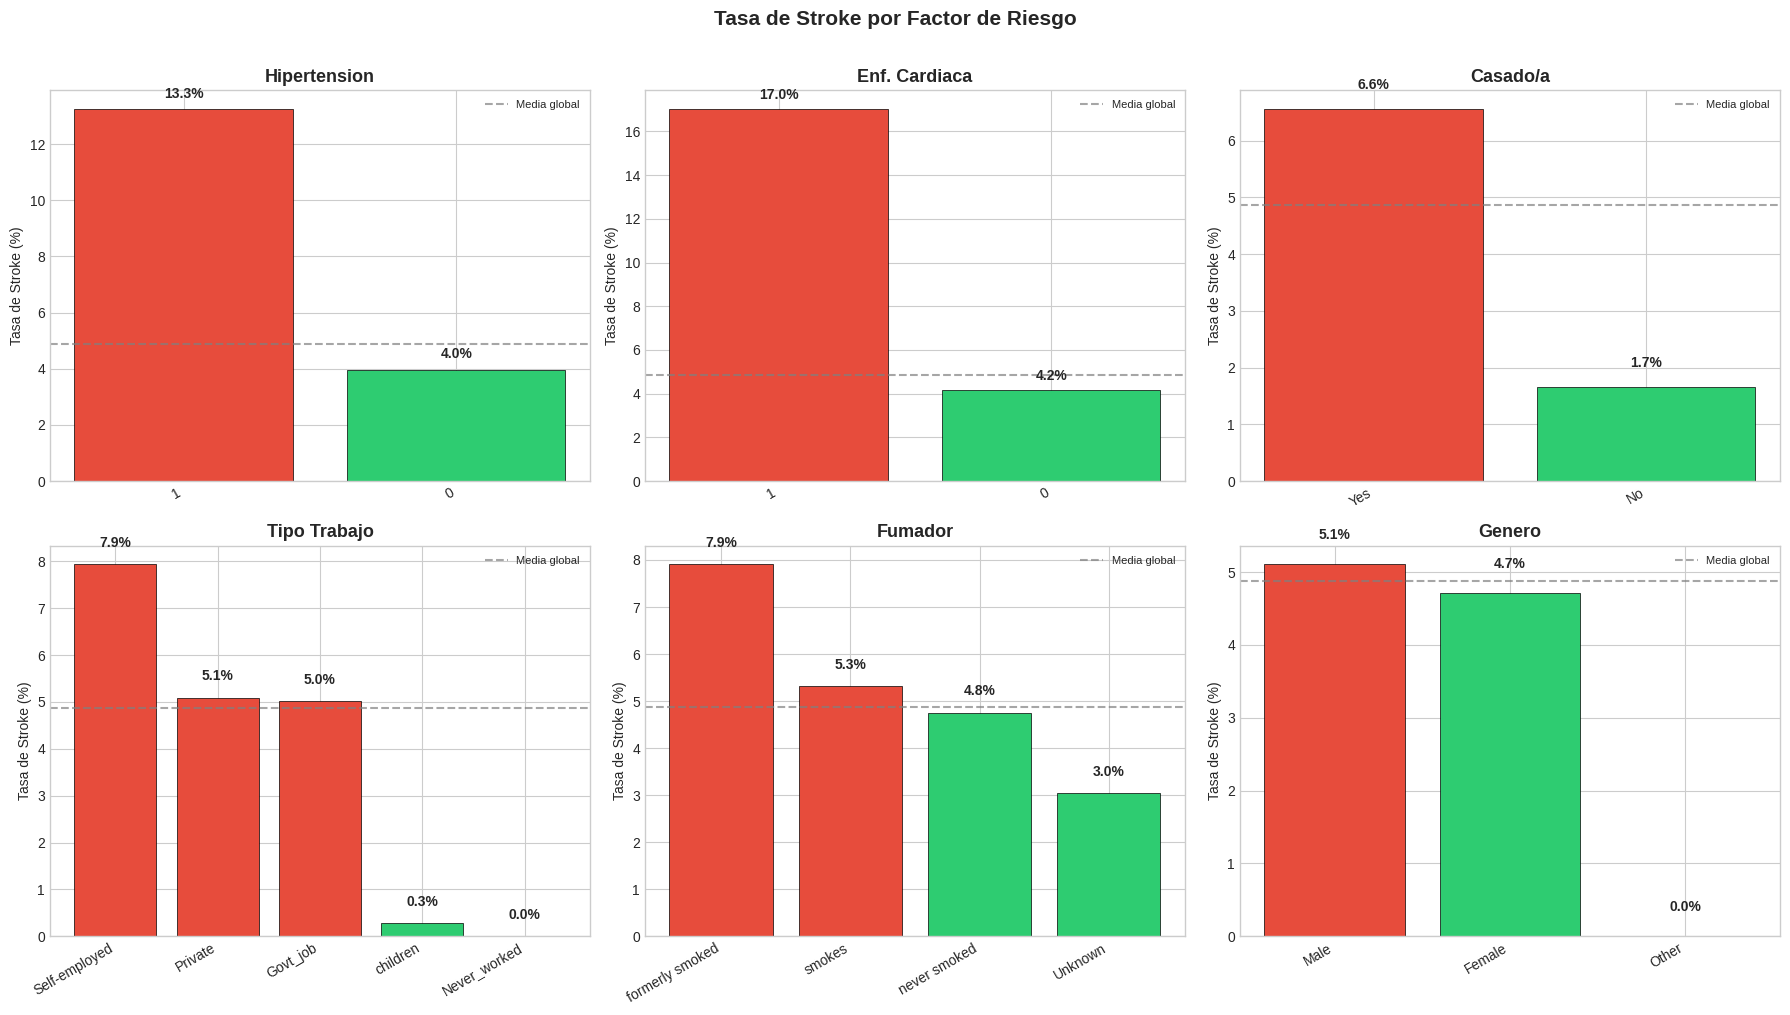

In [16]:
# Visualizacion: tasa de stroke por factor de riesgo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

risk_cols = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 'smoking_status', 'gender']
risk_titles = ['Hipertension', 'Enf. Cardiaca', 'Casado/a', 'Tipo Trabajo', 'Fumador', 'Genero']

for ax, col, title in zip(axes, risk_cols, risk_titles):
    rates = df.groupby(col)['stroke'].mean() * 100
    rates = rates.sort_values(ascending=False)
    
    bar_colors = [STROKE if r > 5 else NO_STROKE for r in rates.values]
    bars = ax.bar(range(len(rates)), rates.values, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels([str(x) for x in rates.index], rotation=30, ha='right')
    
    for bar, rate in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Tasa de Stroke (%)')
    ax.axhline(y=df['stroke'].mean()*100, color='gray', linestyle='--', alpha=0.7, label='Media global')
    ax.legend(fontsize=8)

plt.suptitle('Tasa de Stroke por Factor de Riesgo', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Resumen de Hallazgos

### Senales fuertes
- **Edad** es el factor dominante. El stroke es practicamente inexistente en menores de 40 anios. Mediana de edad en stroke: ~68 vs ~42 sin stroke.
- **Hipertension** duplica (o mas) la tasa de stroke respecto a no hipertensos.
- **Enfermedad cardiaca** previa tiene un efecto similar.
- **Glucosa elevada** muestra asociacion, pero no tan clara como la edad.

### Senales moderadas
- **ever_married = Yes** tiene mas stroke, pero esta altamente correlacionado con edad (la gente mayor suele estar casada).
- **work_type = Self-employed** muestra tasa mas alta, de nuevo confundido con edad.

### Senales debiles o nulas
- **Residence_type** (Urban vs Rural): practicamente igual.
- **Genero**: diferencia minima.
- **BMI**: distribucion similar entre ambos grupos.

### El elefante en la sala
- **Desbalance extremo (95.1% vs 4.9%)** dominara cualquier modelo naive.
- Necesitaremos tecnicas de manejo de desbalance: SMOTE, class_weight, undersampling, o threshold tuning.
- **Accuracy no sirve.** Usar Recall, F1 y AUC-ROC.

### Siguiente paso
Preprocesamiento: imputar BMI, codificar categoricas, escalar, y preparar sets de entrenamiento/prueba listos para modelar.